In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style='whitegrid')

genre_names = ['blues', 'classical', 'country', 'disco', 'hiphop', 
               'jazz', 'metal', 'pop', 'reggae', 'rock']

In [4]:
test  = pd.read_csv('../data/processed/test.csv')
X_test = test.drop(columns=['label'])
y_test = test['label']

rf = joblib.load('../outputs/models/random_forest.pkl')
y_pred = rf.predict(X_test)

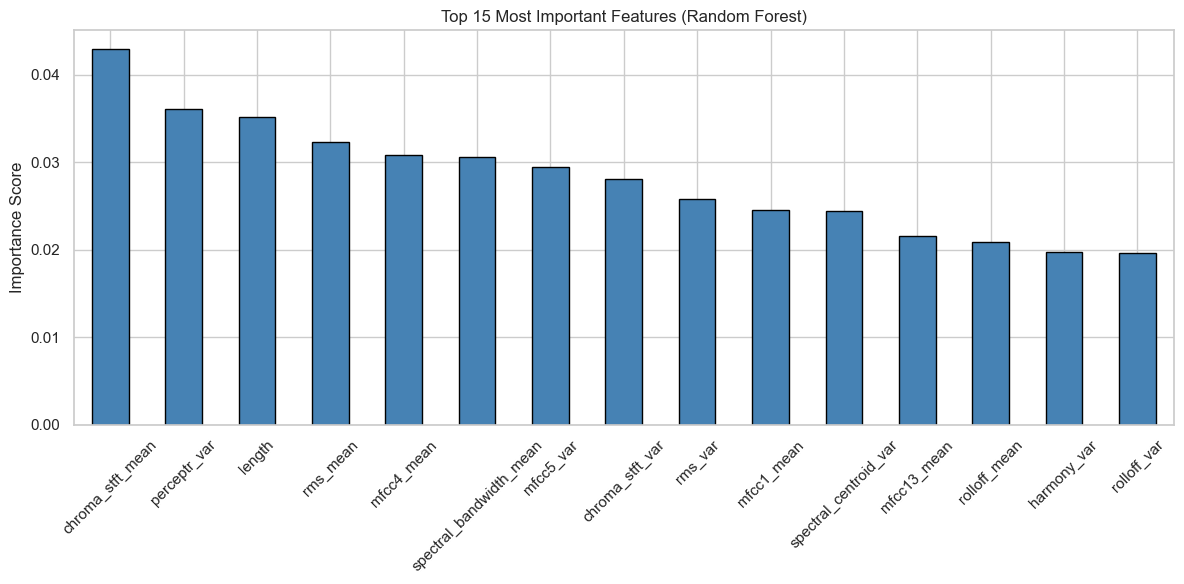

Top 10 features:
chroma_stft_mean           0.042950
perceptr_var               0.036110
length                     0.035170
rms_mean                   0.032356
mfcc4_mean                 0.030818
spectral_bandwidth_mean    0.030644
mfcc5_var                  0.029507
chroma_stft_var            0.028087
rms_var                    0.025856
mfcc1_mean                 0.024562
spectral_centroid_var      0.024484
mfcc13_mean                0.021557
rolloff_mean               0.020919
harmony_var                0.019749
rolloff_var                0.019596
dtype: float64


In [5]:
importances = pd.Series(rf.feature_importances_, index=X_test.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
importances.head(15).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 15 Most Important Features (Random Forest)')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance.png')
plt.show()

print("Top 10 features:")
print(importances.head(15))

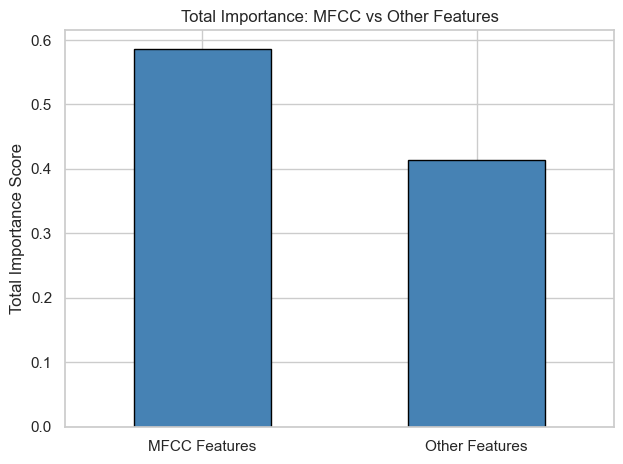

In [6]:
mfcc_importance = importances[importances.index.str.contains('mfcc')].sum()
other_importance = importances[~importances.index.str.contains('mfcc')].sum()

pd.Series({'MFCC Features': mfcc_importance, 
           'Other Features': other_importance}).plot(kind='bar', 
                                                      color='steelblue', 
                                                      edgecolor='black')
plt.title('Total Importance: MFCC vs Other Features')
plt.ylabel('Total Importance Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/figures/mfcc_vs_other_importance.png')
plt.show()

In [7]:
# Find all misclassified songs
test_original = pd.read_csv('../data/raw/features_30_sec.csv')

misclassified = test[y_pred != y_test].copy()
misclassified['predicted'] = y_pred[y_pred != y_test]
misclassified['actual'] = y_test[y_pred != y_test]

print(f"Total misclassified: {len(misclassified)} / {len(y_test)}")
print("\nMost common confusion pairs:")
print(misclassified.groupby(['actual', 'predicted']).size()
      .sort_values(ascending=False).head(10))

Total misclassified: 39 / 150

Most common confusion pairs:
actual  predicted
5       1            3
2       9            3
9       0            3
0       8            2
9       6            2
        5            2
3       4            2
4       3            2
0       4            2
7       4            2
dtype: int64


In [8]:
# Focus on rock since it had the worst f1 score
rock_mask = (y_test == genre_names.index('rock'))
rock_preds = y_pred[rock_mask]

print("When actual genre is Rock, model predicted:")
for genre_idx, count in pd.Series(rock_preds).value_counts().items():
    print(f"  {genre_names[genre_idx]:15s}: {count} times")

When actual genre is Rock, model predicted:
  rock           : 5 times
  blues          : 3 times
  jazz           : 2 times
  metal          : 2 times
  reggae         : 1 times
  hiphop         : 1 times
  country        : 1 times


/var/folders/8h/xd4x3m3961bfgh5q3_c_c6700000gn/T/ipykernel_12123/925670039.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)
/var/folders/8h/xd4x3m3961bfgh5q3_c_c6700000gn/T/ipykernel_12123/925670039.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)
/var/folders/8h/xd4x3m3961bfgh5q3_c_c6700000gn/T/ipykernel_12123/925670039.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)
/var/folders/8h/xd4x3m3961bfgh5q3_c_c6700000gn/T/ipykernel_12123/925670039.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot

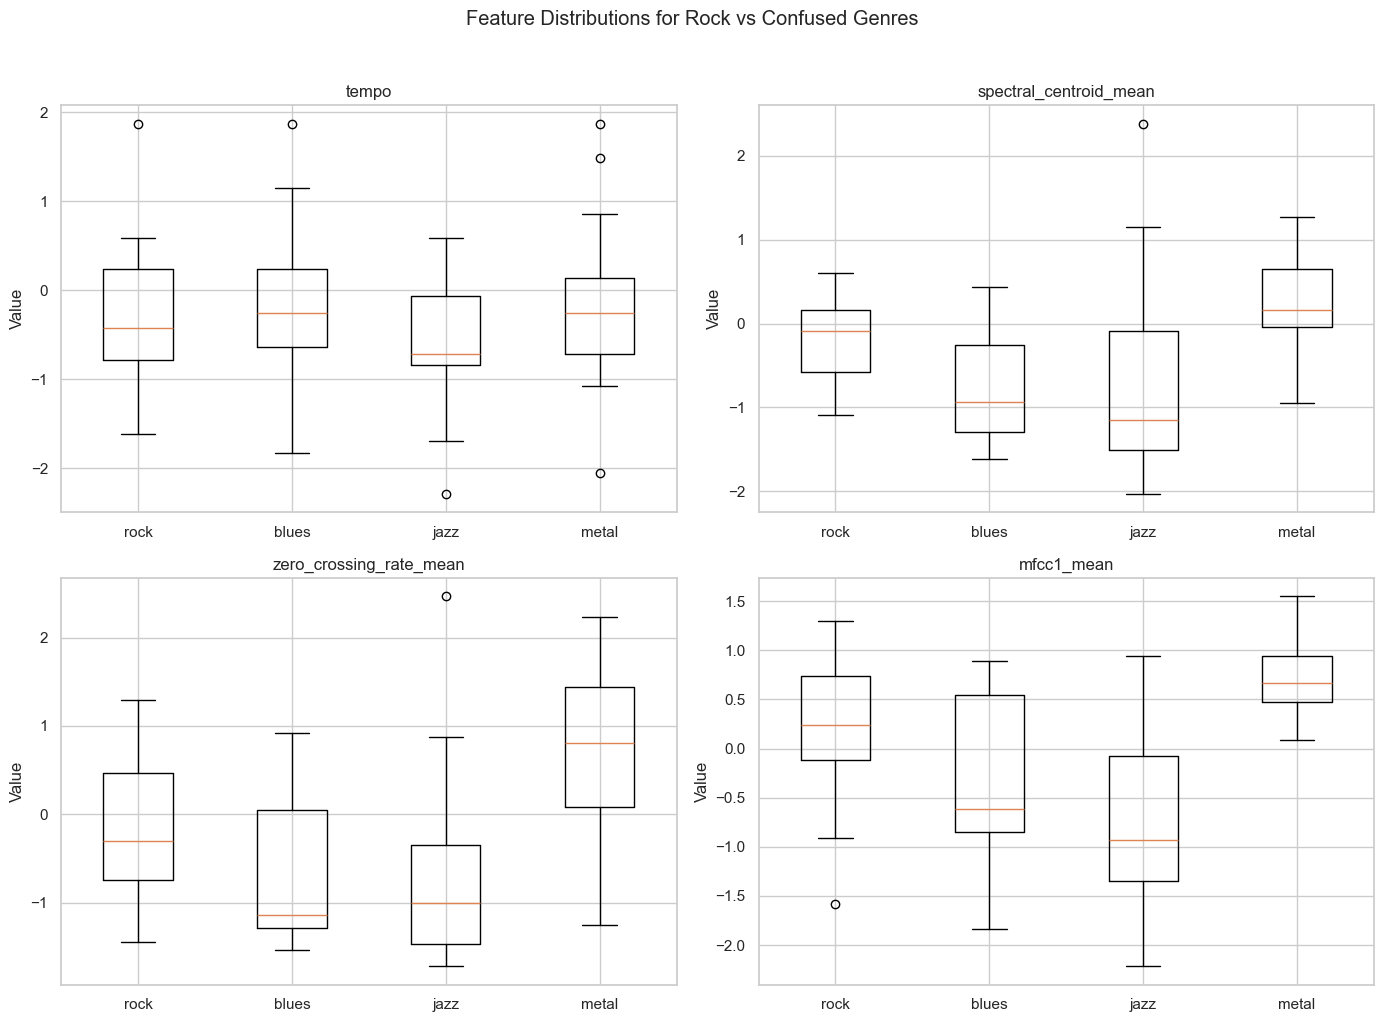

In [12]:
# Compare rock vs the genres it gets confused with
genres_to_compare = ['rock', 'blues', 'jazz', 'metal']
features_to_compare = ['tempo', 'spectral_centroid_mean', 
                       'zero_crossing_rate_mean', 'mfcc1_mean']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.flatten(), features_to_compare):
    data = []
    labels = []
    for genre in genres_to_compare:
        genre_idx = genre_names.index(genre)
        vals = X_test[feature][y_test == genre_idx]
        data.append(vals)
        labels.append(genre)
    ax.boxplot(data, labels=labels)
    ax.set_title(feature)
    ax.set_ylabel('Value')

plt.suptitle('Feature Distributions for Rock vs Confused Genres', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/rock_confusion_features.png')
plt.show()

## Summary

- MFCCs are the most important features overall
- Tempo and spectral centroid also contribute significantly
- Rock is most frequently confused with blues and jazz due to 
  overlapping tempo, spectral centroid, and MFCC distributions
- Classical and pop have the most distinct feature profiles
  which explains their high classification accuracy